# LSI(Latent Semantic Indexing)

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from os import listdir
from os.path import isfile, join
import pandas as pd
import io

In [3]:
import nltk
nltk.download('punkt')
nltk.download('webtext')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package webtext to /root/nltk_data...
[nltk_data]   Unzipping corpora/webtext.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [4]:
from sklearn.datasets import fetch_20newsgroups

categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space',
              'comp.sys.ibm.pc.hardware', 'sci.crypt']


In [5]:
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories)

print('#Train set size:', len(newsgroups_train.data))
print('#Selected categories:', newsgroups_train.target_names)

#Train set size: 3219
#Selected categories: ['alt.atheism', 'comp.graphics', 'comp.sys.ibm.pc.hardware', 'sci.crypt', 'sci.space', 'talk.religion.misc']


In [6]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(token_pattern=r"[\w']{3,}", stop_words='english',\
                     max_features=2000, min_df=5, max_df=0.5)
review_cv = cv.fit_transform(newsgroups_train.data)

print('review_cv', review_cv.shape)

review_cv (3219, 2000)


In [7]:
from nltk.corpus import stopwords
cachedStopWords = stopwords.words("english")

from nltk.tokenize import RegexpTokenizer

RegTok = RegexpTokenizer(r"[\w']{3,}")
english_stops = set(stopwords.words('english'))

def tokenizer(text):
    tokens = RegTok.tokenize(text.lower())
    words = [word for word in tokens if (word not in english_stops) and len(word) > 2]
    return words


texts = [tokenizer(news) for news in newsgroups_train.data]
print(len(texts))
print(texts[0])
print(len(texts[0]))

3219
['livesey', 'solntze', 'wpd', 'sgi', 'com', 'jon', 'livesey', 'subject', 'moraltiy', 'political', 'atheists', 'organization', 'sgi', 'lines', 'nntp', 'posting', 'host', 'solntze', 'wpd', 'sgi', 'com', 'article', '1ql8ekinn635', 'gap', 'caltech', 'edu', 'keith', 'cco', 'caltech', 'edu', 'keith', 'allan', 'schneider', 'writes', 'livesey', 'solntze', 'wpd', 'sgi', 'com', 'jon', 'livesey', 'writes', 'act', 'morally', 'particular', 'reason', 'moral', 'morality', 'instinctive', 'animals', 'saying', 'morality', 'instinctive', 'animals', 'attempt', 'assume', 'conclusion', 'conclusion', 'conclusion', 'correct', 'err', 'behaviour', 'instinctive', 'animals', 'natural', 'moral', 'system', 'see', 'disagreeing', 'definition', 'moral', 'earlier', 'said', 'must', 'conscious', 'act', 'definition', 'instinctive', 'behavior', 'pattern', 'could', 'act', 'morality', 'trying', 'apply', 'human', 'terms', 'non', 'humans', 'pardon', 'trying', 'apply', 'human', 'terms', 'non', 'humans', 'think', 'must', 'c

## GENSIM 이용

In [8]:
!pip install --upgrade gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.9 MB/s eta 0:00:00


In [9]:
from gensim.corpora.dictionary import Dictionary


dictionary = Dictionary(texts)
print('#Number of initial unique words in documents:', len(dictionary))
print(dictionary[0])

dictionary.filter_extremes(keep_n = 2000, no_below=5, no_above=0.5)
print('#Number of unique words after removing rare and common words:', len(dictionary))
print('#Number of unique tokens: %d' % len(dictionary))
print(dictionary[0])


corpus = [dictionary.doc2bow(text) for text in texts]
print('#Number of documents: %d' % len(corpus))
print(corpus[0])
print(len(corpus[0]))
print(len(corpus[1]))


#Number of initial unique words in documents: 46448
1ql8ekinn635
#Number of unique words after removing rare and common words: 2000
#Number of unique tokens: 2000
accept
#Number of documents: 3219
[(0, 1), (1, 3), (2, 1), (3, 1), (4, 1), (5, 1), (6, 5), (7, 3), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 6), (14, 1), (15, 2), (16, 1), (17, 1), (18, 1), (19, 1), (20, 3), (21, 3), (22, 1), (23, 1), (24, 1), (25, 2), (26, 1), (27, 4), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 5), (41, 2), (42, 1), (43, 3), (44, 1), (45, 2), (46, 1), (47, 1), (48, 2), (49, 1), (50, 3), (51, 5), (52, 1), (53, 9), (54, 9), (55, 2), (56, 1), (57, 1), (58, 2), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 2), (67, 1), (68, 1), (69, 1), (70, 1), (71, 1), (72, 1), (73, 2), (74, 2), (75, 1), (76, 1), (77, 4), (78, 2), (79, 1), (80, 6), (81, 1), (82, 3), (83, 1), (84, 1), (85, 1), (86, 2), (87, 5), (88, 1), (89, 1), (9

In [10]:
from gensim.models import LsiModel
num_topics = 10
passes = 5
model = LsiModel(corpus=corpus,
                id2word=dictionary,
                num_topics=num_topics,
)

- 문서-토픽 분포 확인

In [11]:
model[corpus[0]]

[(np.int64(0), np.float64(3.5491723624086897)),
 (np.int64(1), np.float64(-3.099027484133858)),
 (np.int64(2), np.float64(2.904719453920014)),
 (np.int64(3), np.float64(1.404117974616725)),
 (np.int64(4), np.float64(-0.6918758991101107)),
 (np.int64(5), np.float64(1.5070168596839455)),
 (np.int64(6), np.float64(-0.9454541243329186)),
 (np.int64(7), np.float64(-0.9325855709905405)),
 (np.int64(8), np.float64(-0.2793418657224859)),
 (np.int64(9), np.float64(-0.8076882620301509))]

In [12]:
model[corpus[1]]

[(np.int64(0), np.float64(0.7381883437645379)),
 (np.int64(1), np.float64(-0.40762487020080235)),
 (np.int64(2), np.float64(0.07496097400297655)),
 (np.int64(3), np.float64(0.0842444513288016)),
 (np.int64(4), np.float64(0.17447547417436077)),
 (np.int64(5), np.float64(0.41427137036252365)),
 (np.int64(6), np.float64(-0.26580680217573105)),
 (np.int64(7), np.float64(-0.5078526115388102)),
 (np.int64(8), np.float64(0.32372883195900076)),
 (np.int64(9), np.float64(-0.15690486158290967))]

In [13]:
model[corpus[2]]

[(np.int64(0), np.float64(1.7207539778615482)),
 (np.int64(1), np.float64(-0.5791852541644655)),
 (np.int64(2), np.float64(1.277284816591739)),
 (np.int64(3), np.float64(-1.4067553336217662)),
 (np.int64(4), np.float64(-0.25881616174775585)),
 (np.int64(5), np.float64(0.322430037355086)),
 (np.int64(6), np.float64(-0.19792824797536138)),
 (np.int64(7), np.float64(-0.8348077496587911)),
 (np.int64(8), np.float64(0.3243714694225162)),
 (np.int64(9), np.float64(-0.1572281304258519))]

## 찾고자 하는 주제의 수 정하기

In [14]:
from gensim.models import CoherenceModel

In [15]:
start = 1
limit = 11
step = 1

- 토픽응집도

In [16]:
coherence_values_umass = []

for num_topics in range(start, limit, step):
    lsi_model = LsiModel(corpus, num_topics=num_topics, id2word=dictionary)
    coherencemodel = CoherenceModel(model=lsi_model, corpus=corpus, dictionary=dictionary,
                                    coherence='u_mass', topn=10)
    coherence_values_umass.append(coherencemodel.get_coherence())

In [17]:
coherence_values_umass

[np.float64(-1.555549482684295),
 np.float64(-1.5893842834765046),
 np.float64(-2.0194043486603896),
 np.float64(-2.3893720594372168),
 np.float64(-1.8048833444411794),
 np.float64(-1.8730132698285005),
 np.float64(-2.600826535839462),
 np.float64(-2.833569231557989),
 np.float64(-3.5892191308103714),
 np.float64(-2.9809695292269405)]

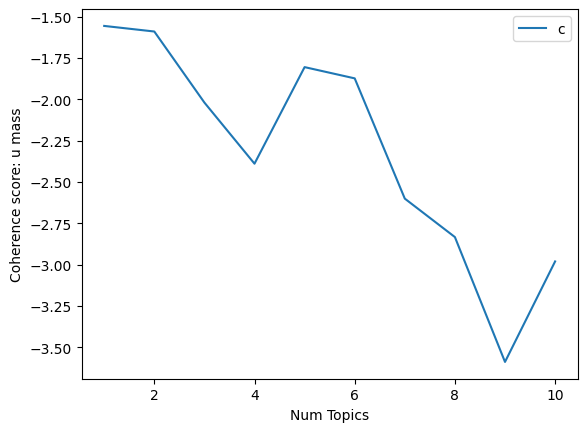

In [18]:
import matplotlib.pyplot as plt
limit=limit; start=start; step=step;
x = range(start, limit, step)
plt.plot(x, coherence_values_umass)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score: u mass")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [19]:
coherence_values_cv = []

for num_topics in range(start, limit, step):
    lsi_model = LsiModel(corpus, num_topics=num_topics, id2word=dictionary)
    coherencemodel = CoherenceModel(model=lsi_model, corpus=corpus, texts=texts, dictionary=dictionary,
                                    coherence='c_v', topn=50)
    coherence_values_cv.append(coherencemodel.get_coherence())

In [20]:
coherence_values_cv

[np.float64(0.3380583405676679),
 np.float64(0.5057176460402191),
 np.float64(0.4261859832588459),
 np.float64(0.4328302116494279),
 np.float64(0.5136034466802553),
 np.float64(0.3580530341055677),
 np.float64(0.4129504643577776),
 np.float64(0.3459879457958243),
 np.float64(0.39455687541595513),
 np.float64(0.3649848914637063)]

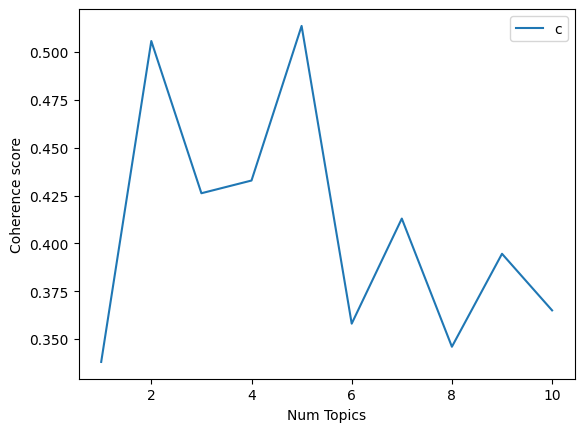

In [21]:
x = range(start, limit, step)
limit=limit; start=start; step=step;
plt.plot(x, coherence_values_cv)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [22]:
num_topics = 5
lsi_model = LsiModel(corpus, num_topics=num_topics, id2word=dictionary)

In [23]:
for topic_id, words in lsi_model.print_topics(num_topics=5, num_words=10):
    print(f"Topic {topic_id}: {words}")

Topic 0: 0.193*"image" + 0.159*"pub" + 0.156*"also" + 0.156*"use" + 0.155*"data" + 0.154*"one" + 0.148*"file" + 0.144*"system" + 0.142*"ftp" + 0.135*"anonymous"
Topic 1: 0.386*"image" + 0.202*"graphics" + 0.174*"images" + -0.162*"one" + -0.156*"people" + -0.153*"would" + 0.152*"gif" + -0.150*"god" + 0.139*"file" + -0.137*"privacy"
Topic 2: 0.284*"privacy" + 0.252*"internet" + 0.219*"pub" + 0.180*"anonymous" + 0.179*"eff" + 0.173*"email" + -0.163*"one" + -0.158*"god" + -0.148*"drive" + 0.146*"information"
Topic 3: 0.375*"drive" + 0.351*"disk" + 0.303*"drives" + 0.247*"hard" + 0.241*"bios" + 0.232*"controller" + 0.210*"rom" + 0.166*"card" + 0.161*"scsi" + 0.145*"floppy"
Topic 4: -0.627*"space" + -0.299*"launch" + -0.201*"nasa" + -0.185*"satellite" + 0.128*"file" + -0.120*"data" + 0.113*"image" + -0.109*"commercial" + -0.104*"satellites" + 0.103*"gif"
